In [2]:
# Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
os.chdir("/Users/cindyj./Desktop/HHX")
df = pd.read_csv('sales.csv')

In [4]:
print(df.head())
print(df.columns)

  Unnamed: 0   1/1/25    1/2/25    1/3/25    1/4/25    1/5/25    1/6/25  \
0       库存数量  14024.0  13927.00  14275.00  13525.00  13268.00  13046.00   
1     销售商品总数    229.0    232.00    192.00    209.00    204.00    289.00   
2  平均销售价格($)     30.5     30.07     29.56     27.93     30.36     26.52   

     1/7/25   1/8/25    1/9/25  ...  12/22/25  12/23/25  12/24/25  12/25/25  \
0  12935.00  12736.0  12550.00  ...  12774.00  12795.00  12648.00  12649.00   
1    269.00    222.0    213.00  ...    194.00    101.00     77.00    104.00   
2     27.99     26.4     26.73  ...     25.75     25.35     25.07     27.42   

   12/26/25  12/27/25  12/28/25  12/29/25  12/30/25  12/31/25  
0  12506.00  12280.00  12150.00  12112.00  12218.00  12751.00  
1    140.00    140.00    165.00    153.00    169.00    137.00  
2     25.79     23.64     24.21     24.67     24.42     27.18  

[3 rows x 366 columns]
Index(['Unnamed: 0', '1/1/25', '1/2/25', '1/3/25', '1/4/25', '1/5/25',
       '1/6/25', '1/7/25', '1/8

In [5]:
df = df.rename(columns={"Unnamed: 0": "Variable"})

In [6]:
print(df.head())
print(df.columns)

    Variable   1/1/25    1/2/25    1/3/25    1/4/25    1/5/25    1/6/25  \
0       库存数量  14024.0  13927.00  14275.00  13525.00  13268.00  13046.00   
1     销售商品总数    229.0    232.00    192.00    209.00    204.00    289.00   
2  平均销售价格($)     30.5     30.07     29.56     27.93     30.36     26.52   

     1/7/25   1/8/25    1/9/25  ...  12/22/25  12/23/25  12/24/25  12/25/25  \
0  12935.00  12736.0  12550.00  ...  12774.00  12795.00  12648.00  12649.00   
1    269.00    222.0    213.00  ...    194.00    101.00     77.00    104.00   
2     27.99     26.4     26.73  ...     25.75     25.35     25.07     27.42   

   12/26/25  12/27/25  12/28/25  12/29/25  12/30/25  12/31/25  
0  12506.00  12280.00  12150.00  12112.00  12218.00  12751.00  
1    140.00    140.00    165.00    153.00    169.00    137.00  
2     25.79     23.64     24.21     24.67     24.42     27.18  

[3 rows x 366 columns]
Index(['Variable', '1/1/25', '1/2/25', '1/3/25', '1/4/25', '1/5/25', '1/6/25',
       '1/7/25', '1/8/2

In [7]:
# Melt (wide → long)
df_long = df.melt(id_vars="Variable", var_name="Date", value_name="Value")

# Pivot to proper structure
df_final = df_long.pivot(index="Date", columns="Variable", values="Value").reset_index()

# Rename columns (VERY IMPORTANT — match Chinese names)
df_final.columns = ["Date", "Inventory", "Sales", "Price"]

print(df_final.head())

      Date  Inventory    Sales  Price
0   1/1/25      30.50  14024.0  229.0
1  1/10/25      28.01  12605.0  227.0
2  1/11/25      27.79  12624.0  228.0
3  1/12/25      27.37  12631.0  237.0
4  1/13/25      28.19  12519.0  214.0


In [8]:
df_final["Date"] = pd.to_datetime(df_final["Date"])

/var/folders/tf/gd1_jxv50h55jshzb_y_r5xm0000gn/T/ipykernel_28147/840692302.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_final["Date"] = pd.to_datetime(df_final["Date"])


In [9]:
df_final = df_final.set_index("Date")

df_weekly = df_final.resample("W").agg({
    "Sales": "sum",
    "Price": "mean",
    "Inventory": "mean"
}).reset_index()

print(df_weekly.head())

        Date    Sales       Price  Inventory
0 2025-01-05  69019.0  213.200000  29.684000
1 2025-01-12  89127.0  240.714286  27.258571
2 2025-01-19  89451.0  183.714286  29.278571
3 2025-01-26  95789.0  172.428571  29.057143
4 2025-02-02  98680.0  147.428571  30.830000


In [10]:
# Time trend
df_weekly["Time"] = range(len(df_weekly))

# Lag variable
df_weekly["Sales_lag1"] = df_weekly["Sales"].shift(1)

# Drop NA
df_weekly = df_weekly.dropna()

In [11]:
X = df_weekly[["Price", "Inventory", "Time", "Sales_lag1"]]
y = df_weekly["Sales"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     45.08
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           1.61e-15
Time:                        23:59:34   Log-Likelihood:                -545.64
No. Observations:                  52   AIC:                             1101.
Df Residuals:                      47   BIC:                             1111.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.111e+04   4.06e+04     -0.273      0.7

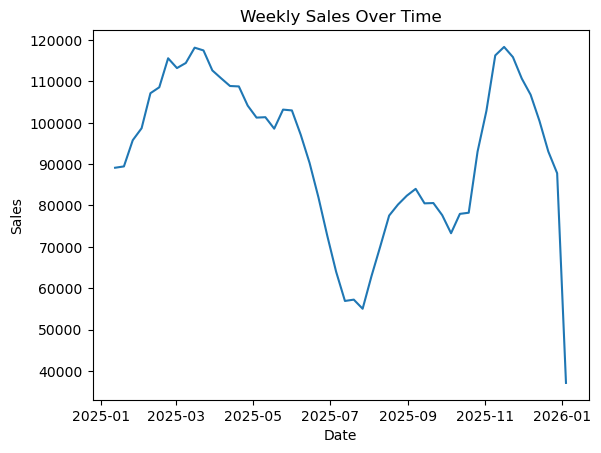

In [12]:
import matplotlib.pyplot as plt

plt.plot(df_weekly["Date"], df_weekly["Sales"])
plt.title("Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()